# ⚖️ Notebook 03 — Data Augmentation & Class Imbalance Handling
### Quality-Aware FER Project

**Dataset:** `dataset/train`, `dataset/validation`, `dataset/test`
**Kelas:** 8 emosi — angry, contempt, disgust, fear, happy, neutral, sad, suprise

**Perubahan v2:**
- Offline augmentation tanpa batas 50 sampel → generate hingga target count
- Augmentasi lebih agresif untuk kelas minoritas
- Simpan `data/augmented/index.csv` untuk dipakai Training notebook

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import torch
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
from pathlib import Path
from PIL import Image
from collections import Counter

# Temukan ROOT project
current_path = Path(".").resolve()
if (current_path / "src").exists() and (current_path / "configs").exists():
    ROOT = current_path
elif (current_path.parent / "src").exists() and (current_path.parent / "configs").exists():
    ROOT = current_path.parent
else:
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
plt.style.use("dark_background")

DATASET_ROOT = ROOT / "dataset"
SAVE_DIR     = ROOT / "results" / "plots" / "eda";   SAVE_DIR.mkdir(parents=True, exist_ok=True)
AUG_DIR      = ROOT / "data"    / "augmented";        AUG_DIR.mkdir(parents=True, exist_ok=True)

EMOTION_CLASSES = ["angry","contempt","disgust","fear","happy","neutral","sad","suprise"]
COLORS = ["#ef4444","#a16207","#a855f7","#f97316","#22c55e","#94a3b8","#3b82f6","#eab308"]
CMAP   = dict(zip(EMOTION_CLASSES, COLORS))

print(f"✅ Dataset root: {DATASET_ROOT}")
print(f"✅ Augment dir : {AUG_DIR}")

# ── Scan dataset ──────────────────────────────────────────────────────────────
records = []
for split in ["train","validation","test"]:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists(): continue
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir(): continue
        for p in list(cls_dir.glob("*.png")) + list(cls_dir.glob("*.jpg")):
            records.append({"path":str(p),"emotion":cls_dir.name.lower(),"split":split})

df       = pd.DataFrame(records)
train_df = df[df["split"]=="train"].reset_index(drop=True)
print(f"Total: {len(df):,} | Train: {len(train_df):,}")

✅ Dataset root: D:\BIG-Data\tuber\dataset
✅ Augment dir : D:\BIG-Data\tuber\data\augmented
Total: 75,914 | Train: 64,000


## 1. Visualisasi Class Imbalance

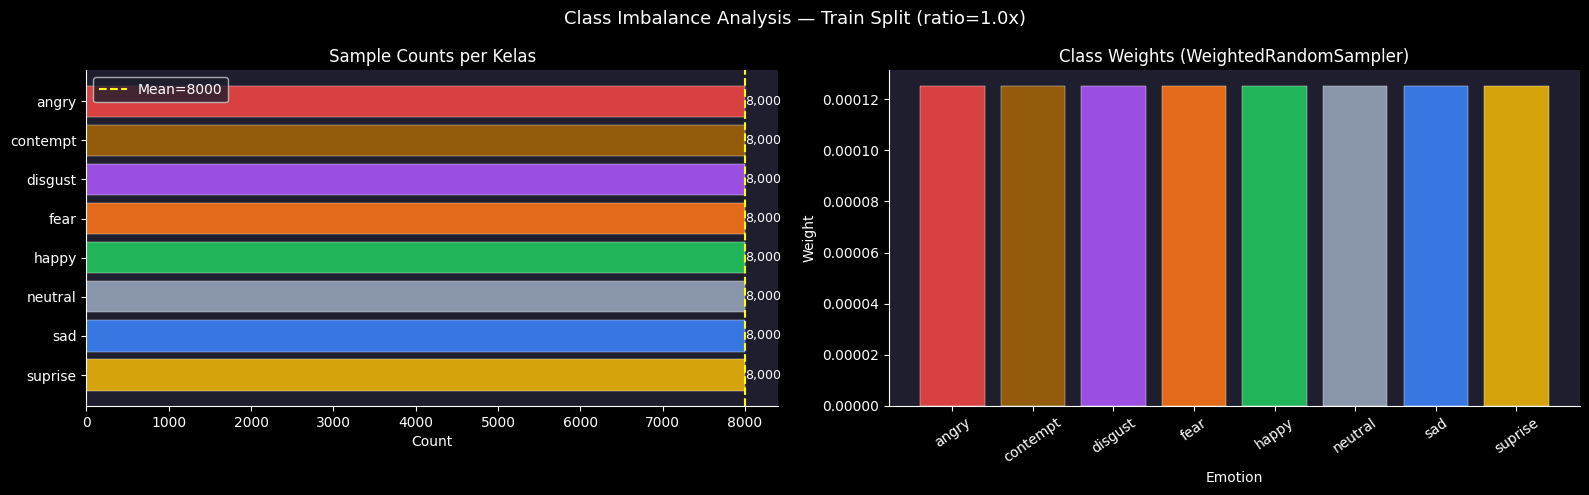

Max: angry (8,000) | Min: angry (8,000)


In [2]:
train_counts = train_df["emotion"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
max_c        = train_counts.max()
min_c        = train_counts[train_counts>0].min()
imbalance_ratio = max_c / max(min_c, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"Class Imbalance Analysis — Train Split (ratio={imbalance_ratio:.1f}x)", fontsize=13, color="white")

ax = axes[0]
bars = ax.barh(train_counts.index[::-1], train_counts.values[::-1],
               color=COLORS[::-1], edgecolor="white", linewidth=0.3, alpha=0.9)
for bar in bars:
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", ha="left", color="white", fontsize=9)
ax.set_title("Sample Counts per Kelas", color="white"); ax.set_xlabel("Count", color="white")
ax.tick_params(colors="white"); ax.set_facecolor("#1e1e2e")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.axvline(train_counts.mean(), color="yellow", linestyle="--", linewidth=1.5,
           label=f"Mean={train_counts.mean():.0f}"); ax.legend(facecolor="#1e1e2e", labelcolor="white")

weights     = 1.0 / (train_counts + 1e-6)
weights_vis = weights.sort_values(ascending=False)
ax2 = axes[1]
ax2.bar(weights_vis.index, weights_vis.values,
        color=[CMAP[e] for e in weights_vis.index], edgecolor="white", linewidth=0.3, alpha=0.9)
ax2.set_title("Class Weights (WeightedRandomSampler)", color="white")
ax2.set_xlabel("Emotion"); ax2.set_ylabel("Weight")
ax2.tick_params(axis="x", rotation=35, colors="white"); ax2.tick_params(axis="y", colors="white")
ax2.set_facecolor("#1e1e2e"); ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR/"augmentation_01_imbalance.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Max: {train_counts.idxmax()} ({max_c:,}) | Min: {train_counts[train_counts>0].idxmin()} ({min_c:,})")

## 2. Demonstrasi Teknik Augmentasi

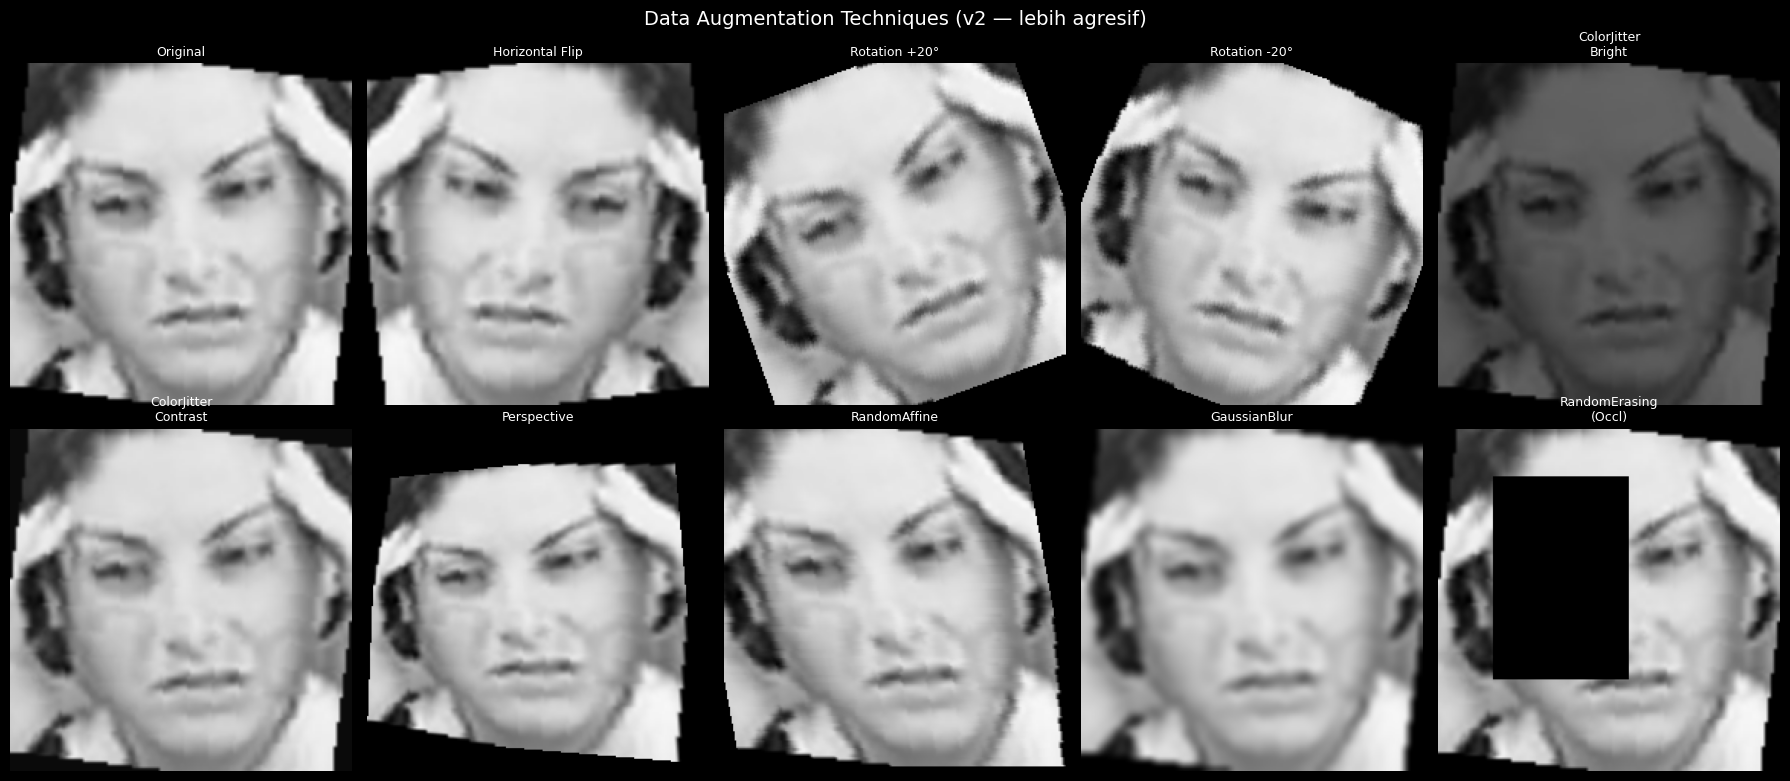

In [3]:
sample_path = train_df[train_df["emotion"]=="sad"].iloc[0]["path"]
pil_img     = Image.open(sample_path).convert("RGB")

augmentations = {
    "Original":               T.Compose([T.Resize((224,224))]),
    "Horizontal Flip":        T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(p=1.0)]),
    "Rotation +20°":          T.Compose([T.Resize((224,224)), T.RandomRotation((20,20))]),
    "Rotation -20°":          T.Compose([T.Resize((224,224)), T.RandomRotation((-20,-20))]),
    "ColorJitter\nBright":    T.Compose([T.Resize((224,224)), T.ColorJitter(brightness=0.7)]),
    "ColorJitter\nContrast":  T.Compose([T.Resize((224,224)), T.ColorJitter(contrast=0.7)]),
    "Perspective":            T.Compose([T.Resize((224,224)), T.RandomPerspective(distortion_scale=0.3, p=1.0)]),
    "RandomAffine":           T.Compose([T.Resize((224,224)), T.RandomAffine(degrees=0, translate=(0.1,0.1), shear=15)]),
    "GaussianBlur":           T.Compose([T.Resize((224,224)), T.GaussianBlur(7, sigma=2.5)]),
    "RandomErasing\n(Occl)":  T.Compose([T.Resize((224,224)), T.ToTensor(),
                                          T.RandomErasing(p=1.0, scale=(0.05,0.25), value=0), T.ToPILImage()]),
}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Data Augmentation Techniques (v2 — lebih agresif)", fontsize=14, color="white")
axes = axes.flatten()
for i, (name, aug) in enumerate(augmentations.items()):
    try:
        aug_img = aug(pil_img)
        if isinstance(aug_img, torch.Tensor): aug_img = T.ToPILImage()(aug_img)
        axes[i].imshow(aug_img)
    except:
        axes[i].imshow(pil_img.resize((224,224)))
    axes[i].set_title(name, color="white", fontsize=9); axes[i].axis("off")

plt.tight_layout()
plt.savefig(SAVE_DIR/"augmentation_02_techniques.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 3. Full Training Augmentation Pipeline

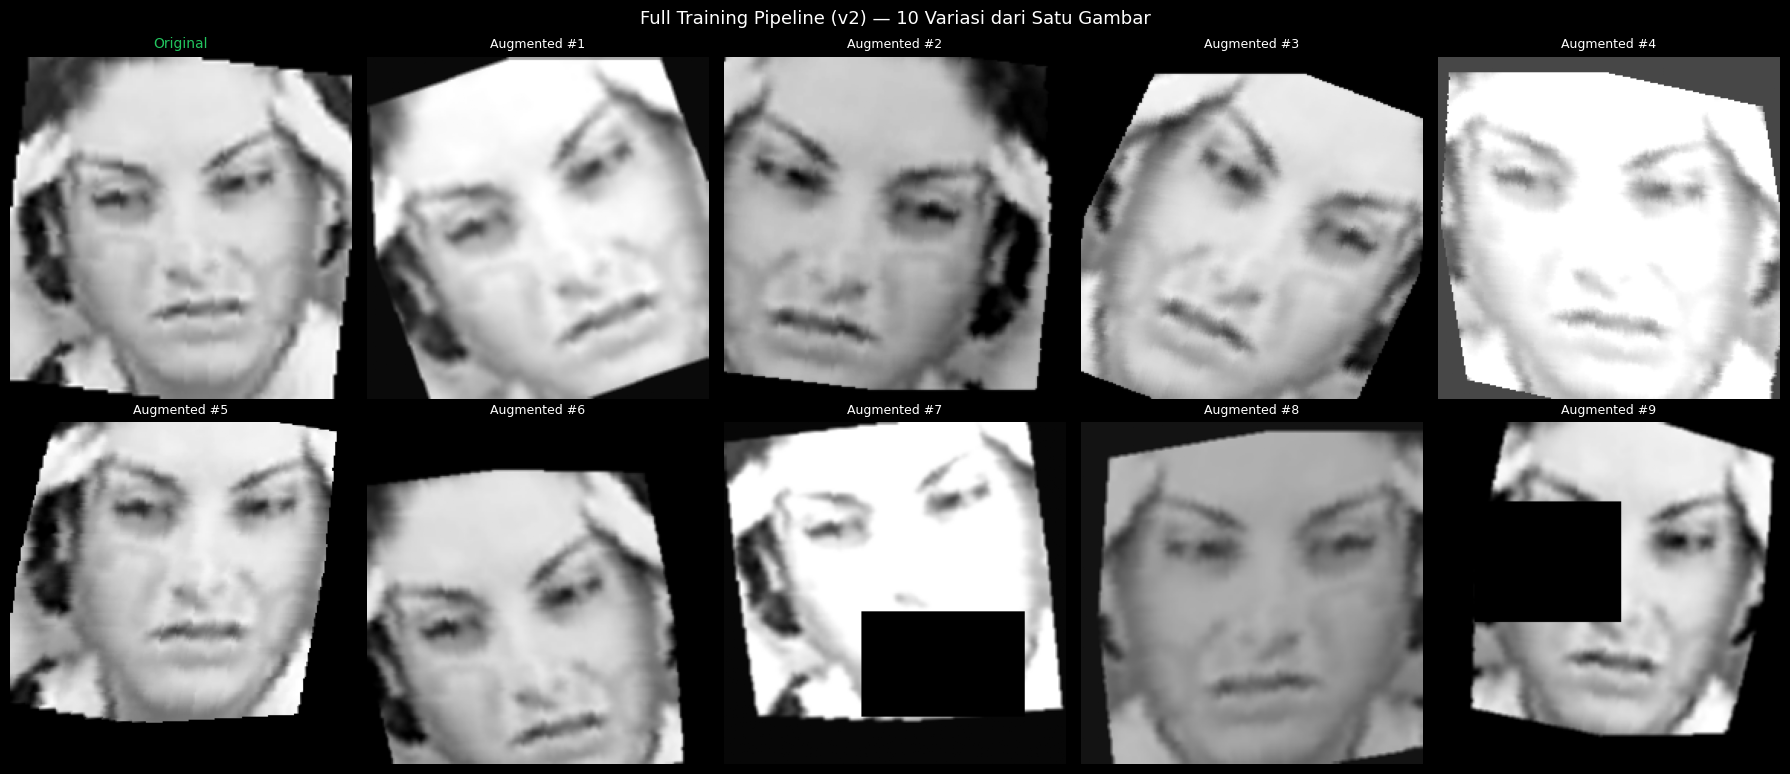

In [4]:
TRAIN_AUG = T.Compose([
    T.Resize((224+32, 224+32), interpolation=InterpolationMode.BILINEAR),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.RandomAffine(degrees=0, translate=(0.08,0.08), shear=10),
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.08),
    T.RandomGrayscale(p=0.15),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02,0.20), value=0),
])

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Full Training Pipeline (v2) — 10 Variasi dari Satu Gambar", fontsize=13, color="white")
axes = axes.flatten()

axes[0].imshow(pil_img.resize((224,224))); axes[0].set_title("Original", color="#22c55e", fontsize=10)
axes[0].axis("off")

for i in range(1, 10):
    aug_t  = TRAIN_AUG(pil_img)
    aug_np = aug_t.permute(1,2,0).numpy().clip(0,1)
    axes[i].imshow(aug_np); axes[i].set_title(f"Augmented #{i}", color="white", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(SAVE_DIR/"augmentation_03_pipeline_samples.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 4. WeightedRandomSampler — Before vs After

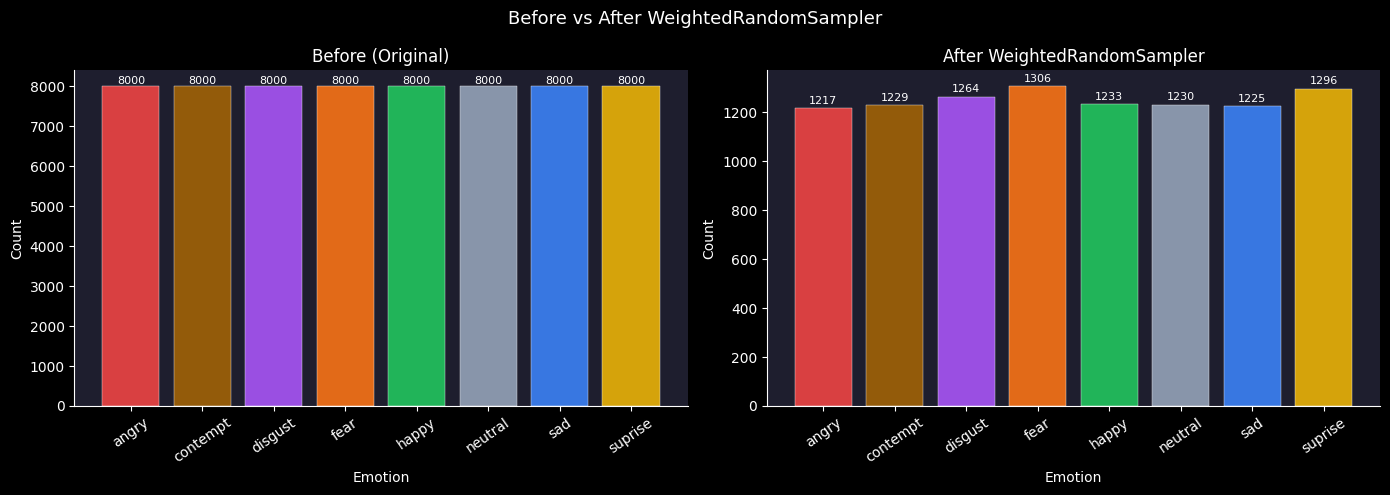

In [5]:
from torch.utils.data import WeightedRandomSampler

labels_arr        = train_df["emotion"].map({e:i for i,e in enumerate(EMOTION_CLASSES)}).values
class_counts_arr  = np.bincount(labels_arr, minlength=len(EMOTION_CLASSES)).astype(float)
class_weights_arr = 1.0 / (class_counts_arr + 1e-6)
sample_weights    = class_weights_arr[labels_arr]

sampler   = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights), replacement=True,
)
simulated = list(sampler)[:min(10000, len(sample_weights))]
sim_labels = labels_arr[simulated]
sim_counts = pd.Series({EMOTION_CLASSES[k]: v for k, v in Counter(sim_labels).items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Before vs After WeightedRandomSampler", fontsize=13, color="white")
for ax, data, title in [
    (axes[0], train_counts, "Before (Original)"),
    (axes[1], sim_counts.reindex(EMOTION_CLASSES, fill_value=0), "After WeightedRandomSampler"),
]:
    ax.bar(data.index, data.values, color=COLORS, edgecolor="white", linewidth=0.3, alpha=0.9)
    for i, (idx, val) in enumerate(data.items()):
        ax.text(i, val+10, str(int(val)), ha="center", va="bottom", fontsize=8, color="white")
    ax.set_title(title, color="white"); ax.set_xlabel("Emotion"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=35, colors="white"); ax.tick_params(axis="y", colors="white")
    ax.set_facecolor("#1e1e2e"); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR/"augmentation_04_balancing.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 5. Offline Augmentation untuk Kelas Minoritas (Tanpa Batas)

Berbeda dengan versi sebelumnya yang membatasi 50 sampel,
di sini kita generate **sampai target count** untuk semua kelas minoritas.
Hasil disimpan ke `data/augmented/<kelas>/aug_XXXXX.jpg`

In [6]:
# Target = median count (lebih konservatif dari max, lebih aman dari mean)
MINORITY_THRESHOLD = int(train_counts.mean() * 0.6)
TARGET_COUNT       = int(train_counts.median())

minority_classes = train_counts[train_counts < MINORITY_THRESHOLD].index.tolist()
print(f"Minority threshold : {MINORITY_THRESHOLD:,}  (mean × 0.6)")
print(f"Target count       : {TARGET_COUNT:,}  (median train count)")
print(f"Minority classes   : {minority_classes}")
print()

MINORITY_AUG = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=25),
    T.RandomPerspective(distortion_scale=0.25, p=0.4),
    T.RandomAffine(degrees=0, translate=(0.1,0.1), shear=15),
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0)),
])

aug_records = []  # untuk index.csv
total_saved = 0

for emo in minority_classes:
    subset  = train_df[train_df["emotion"]==emo]
    orig_n  = len(subset)
    needed  = max(0, TARGET_COUNT - orig_n)
    out_dir = AUG_DIR / emo
    out_dir.mkdir(parents=True, exist_ok=True)

    saved_n = 0
    rng     = np.random.default_rng(42)

    for i in range(needed):
        row_idx = int(rng.integers(0, len(subset)))
        row     = subset.iloc[row_idx]
        try:
            img = Image.open(row["path"]).convert("RGB")
            aug = MINORITY_AUG(img)
            out_path = str(out_dir / f"aug_{i:06d}.jpg")
            aug.save(out_path)
            aug_records.append({"path": out_path, "emotion": emo, "split": "train"})
            saved_n += 1
        except Exception as e:
            pass

    total_saved += saved_n
    bar_before  = "█" * min(20, orig_n // max(1, max_c//20))
    bar_after   = "█" * min(20, (orig_n+saved_n) // max(1, max_c//20))
    print(f"  {emo:<14}: {orig_n:>5,} → {orig_n+saved_n:>5,} (+{saved_n:>5,} aug)  "
          f"[{bar_before:<20}] → [{bar_after:<20}]")

# Simpan index CSV
if aug_records:
    aug_df = pd.DataFrame(aug_records)
    index_path = AUG_DIR / "index.csv"
    aug_df.to_csv(index_path, index=False)
    print(f"\n✅ Total augmented: {total_saved:,} gambar")
    print(f"   Index CSV saved: {index_path}")
else:
    print("\n✅ Semua kelas sudah melewati threshold, tidak ada augmentasi diperlukan.")

Minority threshold : 4,800  (mean × 0.6)
Target count       : 8,000  (median train count)
Minority classes   : []


✅ Semua kelas sudah melewati threshold, tidak ada augmentasi diperlukan.


## 6. Distribusi Akhir (Original + Augmented)

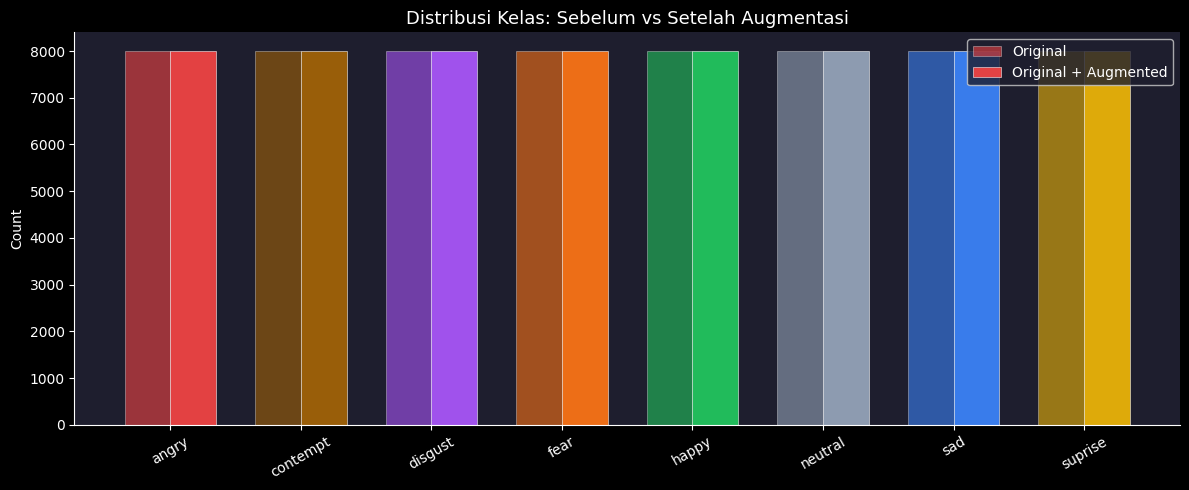


📋 Strategi Balancing yang diterapkan:
   1. WeightedRandomSampler — di DataLoader (online, no disk overhead)
   2. Offline Oversampling  — augmented images ke data/augmented/
   3. Focal Loss γ=2.0     — di loss function (downweight easy samples)
   4. Label Smoothing ε=0.1 — mencegah over-confidence

➡️  Next: Notebook 04 — Model Training


In [7]:
# Gabung distribusi
aug_counts = pd.Series({emo: 0 for emo in EMOTION_CLASSES})
if aug_records:
    aug_df_tmp = pd.DataFrame(aug_records)
    aug_counts_tmp = aug_df_tmp["emotion"].value_counts()
    for emo in aug_counts_tmp.index:
        if emo in aug_counts.index:
            aug_counts[emo] = aug_counts_tmp[emo]

final_counts = train_counts + aug_counts

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(EMOTION_CLASSES))
w = 0.35
ax.bar(x - w/2, train_counts.values, width=w, color=COLORS, alpha=0.6,
       edgecolor="white", linewidth=0.4, label="Original")
ax.bar(x + w/2, final_counts.values, width=w, color=COLORS, alpha=0.95,
       edgecolor="white", linewidth=0.4, label="Original + Augmented")
for i, (o, f) in enumerate(zip(train_counts.values, final_counts.values)):
    if f > o:
        ax.annotate(f"+{f-o:,}", xy=(i+w/2, f), ha="center", va="bottom",
                    color="#22c55e", fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(EMOTION_CLASSES, rotation=30, color="white")
ax.set_title("Distribusi Kelas: Sebelum vs Setelah Augmentasi", color="white", fontsize=13)
ax.set_ylabel("Count", color="white"); ax.tick_params(axis="y", colors="white")
ax.set_facecolor("#1e1e2e"); ax.legend(facecolor="#1e1e2e", labelcolor="white")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR/"augmentation_05_final_dist.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("\n📋 Strategi Balancing yang diterapkan:")
print("   1. WeightedRandomSampler — di DataLoader (online, no disk overhead)")
print("   2. Offline Oversampling  — augmented images ke data/augmented/")
print("   3. Focal Loss γ=2.0     — di loss function (downweight easy samples)")
print("   4. Label Smoothing ε=0.1 — mencegah over-confidence")
print("\n➡️  Next: Notebook 04 — Model Training")